In [1]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\luigi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
!pip install numpy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\luigi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
#!pip install numpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 2.4.5
Pandas: 3.0.3


In [4]:
#Criando arrays e operações básiacs
a = np.array([1, 2, 3, 4, 5])
b = np.array([10, 20, 30, 40, 50])

print("a:", a)
print("b:", b)

# operações vetorizadas (sem loop explícito)
print("a + b:", a + b)
print("a * 2:", a * 2)
print("a^2:", a ** 2)

print("Média de a:", a.mean())
print("Soma de a:", a.sum())

a: [1 2 3 4 5]
b: [10 20 30 40 50]
a + b: [11 22 33 44 55]
a * 2: [ 2  4  6  8 10]
a^2: [ 1  4  9 16 25]
Média de a: 3.0
Soma de a: 15


In [5]:
#Reshape, operações e matrizes
m = np.arange(1, 13)  # 1..12
m2 = m.reshape(3, 4)  # 3 linhas, 4 colunas

print("m2:\n", m2)

print("Linha 0:", m2[0])
print("Coluna 1:", m2[:, 1])

print("Soma por linha:", m2.sum(axis=1))
print("Soma por coluna:", m2.sum(axis=0))
     

m2:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Linha 0: [1 2 3 4]
Coluna 1: [ 2  6 10]
Soma por linha: [10 26 42]
Soma por coluna: [15 18 21 24]


In [6]:
df = pd.DataFrame({
    "nome": ["Ana", "Bruno", "Carla", "Diego"],
    "idade": [20, 25, 23, 28],
    "cidade": ["SP", "RJ", "MG", "SP"],
    "salario": [2500, 4000, 3200, 5000]
})

df

,nome,idade,cidade,salario
0,Ana,20,SP,2500
1,Bruno,25,RJ,4000
2,Carla,23,MG,3200
3,Diego,28,SP,5000


In [7]:
#Selecionando colunas e filtros
print("Coluna idade:")
display(df["idade"])

print("\nLinhas com cidade == 'SP':")
display(df[df["cidade"] == "SP"])

print("\nLinhas com salario >= 3500:")
display(df[df["salario"] >= 3500])
     

Coluna idade:


0    20
1    25
2    23
3    28
Name: idade, dtype: int64


Linhas com cidade == 'SP':


,nome,idade,cidade,salario
0,Ana,20,SP,2500
3,Diego,28,SP,5000



Linhas com salario >= 3500:


,nome,idade,cidade,salario
1,Bruno,25,RJ,4000
3,Diego,28,SP,5000


In [8]:
#Estatísticas descritivas rápidas

display(df.describe())

print("\nTipos das colunas:")
print(df.dtypes)

print("\nValores únicos em cidade:")
print(df["cidade"].unique())
     

,idade,salario
count,4.000000,4.000000
mean,24.000000,3675.000000
std,3.366502,1075.096895
min,20.000000,2500.000000
25%,22.250000,3025.000000
50%,24.000000,3600.000000
75%,25.750000,4250.000000
max,28.000000,5000.000000



Tipos das colunas:
nome         str
idade      int64
cidade       str
salario    int64
dtype: object

Valores únicos em cidade:
<StringArray>
['SP', 'RJ', 'MG']
Length: 3, dtype: str


In [9]:
#Groupby : Agrupamento por categoria

media_salario_por_cidade = df.groupby("cidade")["salario"].mean().sort_values(ascending=False)
media_salario_por_cidade

cidade
RJ    4000.0
SP    3750.0
MG    3200.0
Name: salario, dtype: float64

In [10]:
df_nan = df.copy()
df_nan.loc[2, "salario"] = np.nan  # cria um NaN proposital

display(df_nan)

print("\nQuantidade de NaN por coluna:")
print(df_nan.isna().sum())

print("\nPreenchendo NaN com a média da coluna salario:")
df_nan["salario"] = df_nan["salario"].fillna(df_nan["salario"].mean())

display(df_nan)

,nome,idade,cidade,salario
0,Ana,20,SP,2500.0
1,Bruno,25,RJ,4000.0
2,Carla,23,MG,NaN
3,Diego,28,SP,5000.0



Quantidade de NaN por coluna:
nome       0
idade      0
cidade     0
salario    1
dtype: int64

Preenchendo NaN com a média da coluna salario:


,nome,idade,cidade,salario
0,Ana,20,SP,2500.000000
1,Bruno,25,RJ,4000.000000
2,Carla,23,MG,3833.333333
3,Diego,28,SP,5000.000000


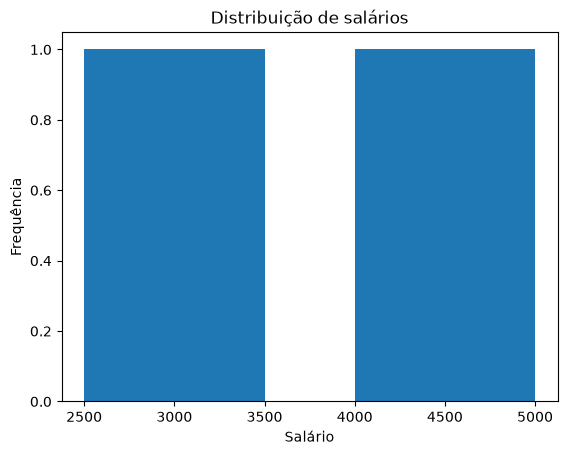

In [11]:
#Histograma : Distribuição de uma variavel numerica
plt.figure()
plt.hist(df["salario"], bins=5)
plt.title("Distribuição de salários")
plt.xlabel("Salário")
plt.ylabel("Frequência")
plt.show()

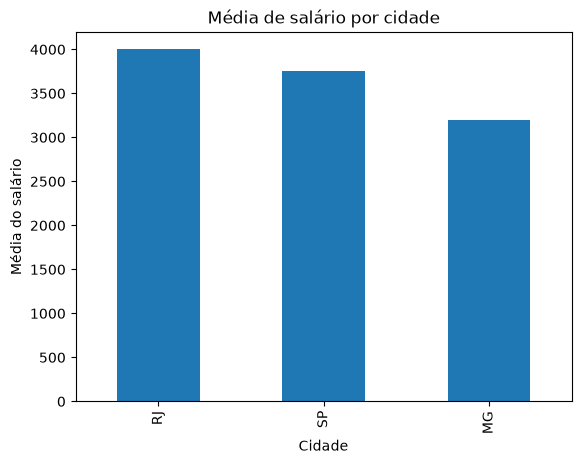

In [12]:
## Barras : Media por categoria
plt.figure()
media_salario_por_cidade.plot(kind="bar")
plt.title("Média de salário por cidade")
plt.xlabel("Cidade")
plt.ylabel("Média do salário")
plt.show()
     

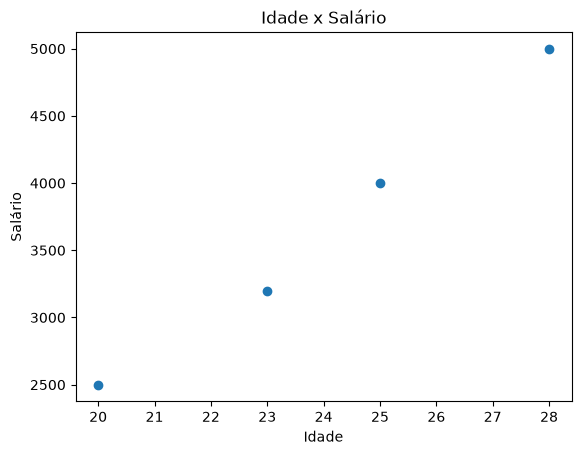

In [13]:
#Dispersão ( idade x salário)
plt.figure()
plt.scatter(df["idade"], df["salario"])
plt.title("Idade x Salário")
plt.xlabel("Idade")
plt.ylabel("Salário")
plt.show()

In [14]:
## Carregando o datset da iris
from sklearn.datasets import load_iris
import pandas as pd

df = pd.read_csv(r'C:\Users\luigi\Downloads\Fraud.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [15]:
# Checar a estrutura do dataset
print("Shape:", df.shape)

print("\nTipos:")
print(df.dtypes)

print("\nPrimeiras linhas:")
print(df.head())

Shape: (6362620, 11)

Tipos:
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Primeiras linhas:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0       

In [16]:
#Checando valores ausentes
df.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [17]:
#Estatísticas descritivas(numericas)
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [18]:
#Entendendo categorias (espécies)
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

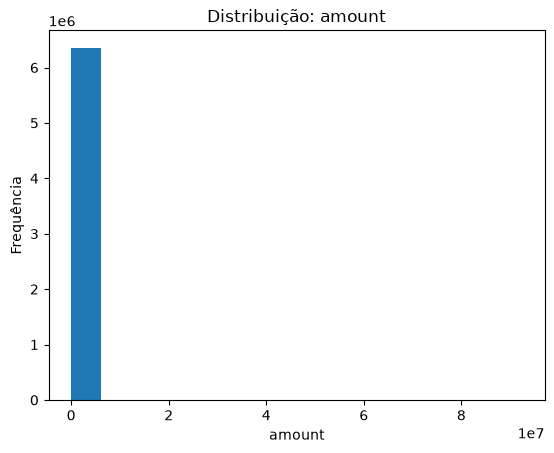

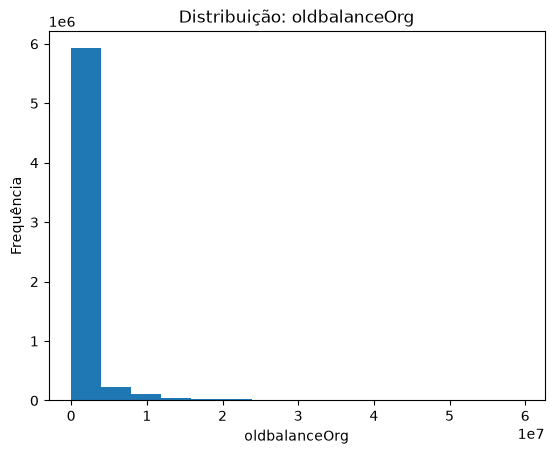

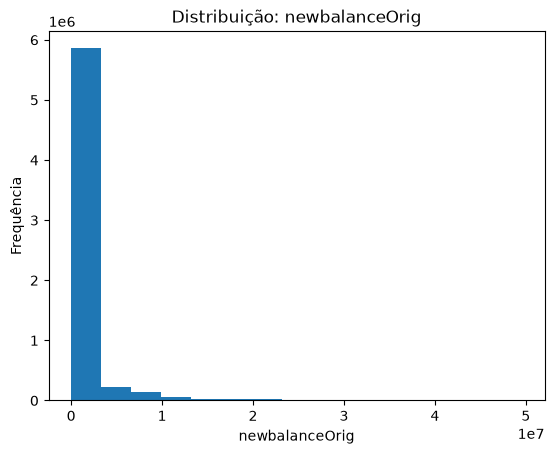

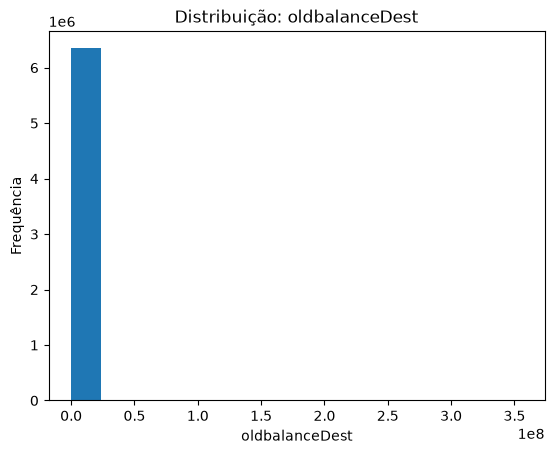

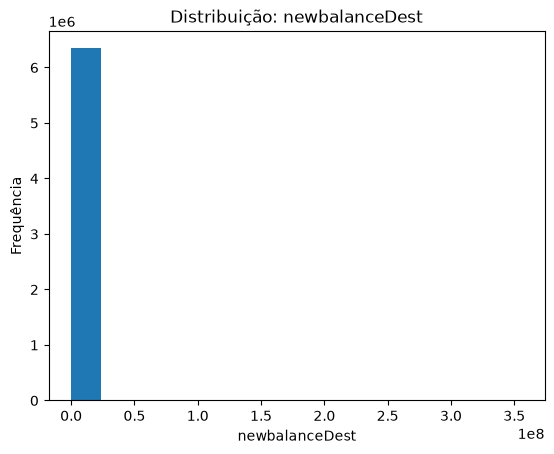

In [19]:
#Distribuição (histogramas) das features

cols = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

for col in cols:
    plt.figure()
    plt.hist(df[col], bins=15)
    plt.title(f"Distribuição: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.show()

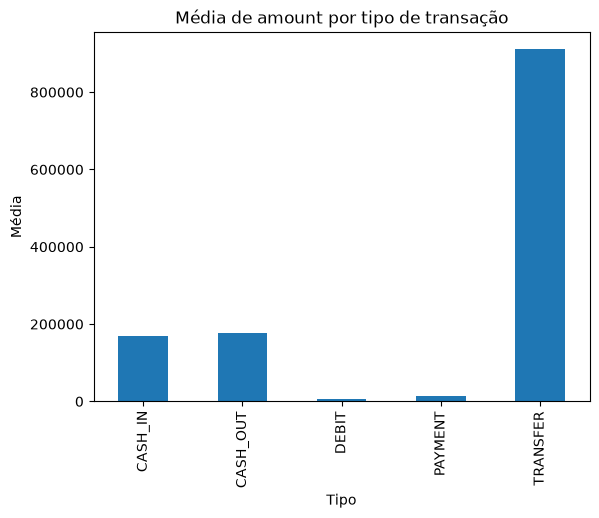

In [20]:
media_por_tipo = df.groupby("type").mean(numeric_only=True)

plt.figure()
media_por_tipo["amount"].plot(kind="bar")
plt.title("Média de amount por tipo de transação")
plt.xlabel("Tipo")
plt.ylabel("Média")
plt.show()

C:\Users\luigi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


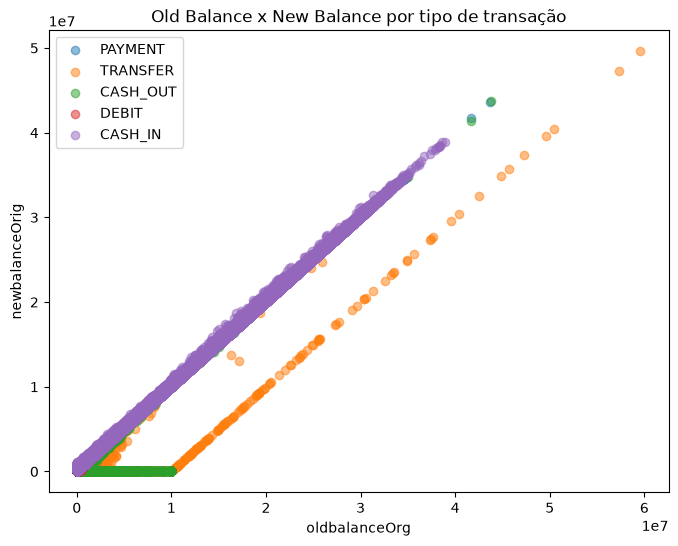

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for tp in df["type"].unique():
    sub = df[df["type"] == tp]
    plt.scatter(
        sub["oldbalanceOrg"],
        sub["newbalanceOrig"],
        label=tp,
        alpha=0.5
    )

plt.title("Old Balance x New Balance por tipo de transação")
plt.xlabel("oldbalanceOrg")
plt.ylabel("newbalanceOrig")
plt.legend()
plt.show()

In [22]:
#Correlações (para variaveis numericas)
corr = df[cols].corr()
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000


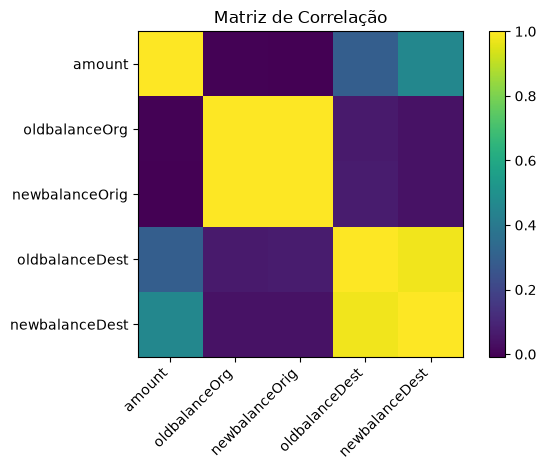

In [23]:
#  Heatmap simples (sem seaborn, só com matplotlib)


plt.figure()
plt.imshow(corr.values)
plt.title("Matriz de Correlação")
plt.xticks(range(len(cols)), cols, rotation=45, ha="right")
plt.yticks(range(len(cols)), cols)
plt.colorbar()
plt.tight_layout()
plt.show()
     